# C2 — Image Backbone Screening Report

Laporan *read-only* untuk screening DenseNet-121, ResNet-50, dan EfficientNet-B0 dengan ImageNet initialization serta frozen protocol yang sama.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import precision_recall_curve, roc_curve

def find_project_root(start=Path.cwd()):
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'run_experiment.py').is_file():
            return candidate
    raise FileNotFoundError('Project root tidak ditemukan')

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.reporting.canonical import (
    fold_metric_frame, load_canonical_context, load_oof_predictions, metric_table
)

context = load_canonical_context(PROJECT_ROOT)
model_lock = json.loads((context.protocol_dir / 'model_lock.json').read_text(encoding='utf-8'))
pd.DataFrame([{
    'protocol_version': '1.0.0',
    'status': context.protocol['status'],
    'protocol_hash': context.protocol_hash,
    'model_lock_status': model_lock['status'],
    'selected_backbone': model_lock['selected_backbone'],
    'selected_pretraining': model_lock['selected_pretraining'],
}])

,protocol_version,status,protocol_hash,model_lock_status,selected_backbone,selected_pretraining
0,1.0.0,FROZEN,d42337690181f1054297f514934ad0c98bb718223bc06d...,LOCKED,resnet50,imagenet


## Audit artifact dan metric screening

Metric di bawah diregenerasi dari pooled OOF prediction. Tidak ada official NIH test yang dibaca.

In [2]:
stage_dir = context.protocol_dir / 'screening' / 'image'
files = {
    'DenseNet-121': 'densenet121-imagenet-oof.csv',
    'ResNet-50': 'resnet50-imagenet-oof.csv',
    'EfficientNet-B0': 'efficientnet_b0-imagenet-oof.csv',
}
models = {
    name: load_oof_predictions(
        context, stage_dir / filename, expected_stage_directory='screening/image'
    )
    for name, filename in files.items()
}
summary = metric_table(models).sort_values('roc_auc_pooled', ascending=False)
display(summary.style.format({
    column: '{:.4f}' for column in summary.columns if column not in {'n_images', 'n_patients'}
}))
print('Audit PASS:', all(len(frame) == len(context.folds) for frame in models.values()))

,roc_auc_pooled,roc_auc_mean,roc_auc_sd,ap_pooled,ap_mean,ap_sd,brier_score,accuracy_0.5,sensitivity_0.5,specificity_0.5,f1_0.5,n_images,n_patients
model,,,,,,,,,,,,,
ResNet-50,0.7524,0.7535,0.0022,0.6729,0.6742,0.0031,0.2002,0.7045,0.6264,0.7602,0.6383,86524,28008
EfficientNet-B0,0.7505,0.7512,0.0019,0.6706,0.6718,0.0057,0.2005,0.7016,0.6158,0.7629,0.6322,86524,28008
DenseNet-121,0.7448,0.7458,0.0024,0.6645,0.6655,0.0015,0.2024,0.6966,0.6118,0.7570,0.6267,86524,28008


Audit PASS: True


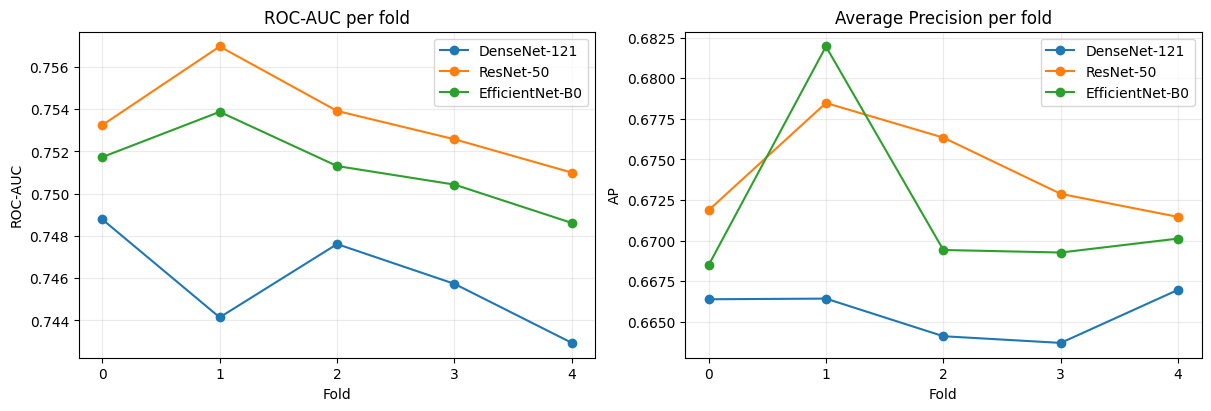

In [3]:
folds = fold_metric_frame(models)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for name, group in folds.groupby('model', sort=False):
    axes[0].plot(group['fold'], group['roc_auc'], marker='o', label=name)
    axes[1].plot(group['fold'], group['average_precision'], marker='o', label=name)
axes[0].set(title='ROC-AUC per fold', xlabel='Fold', ylabel='ROC-AUC', xticks=range(5))
axes[1].set(title='Average Precision per fold', xlabel='Fold', ylabel='AP', xticks=range(5))
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
plt.show()

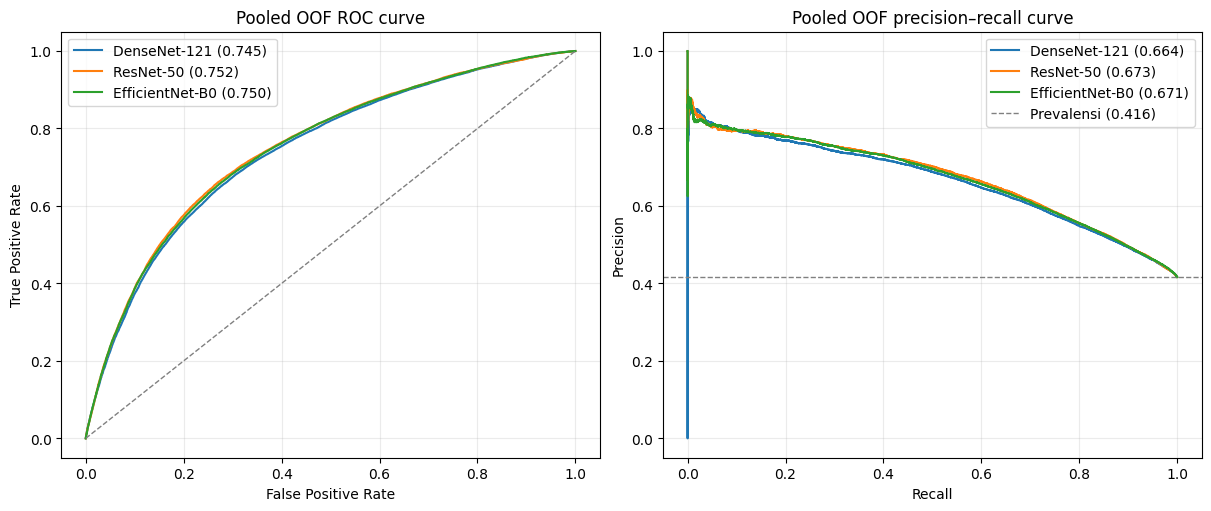

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
prevalence = next(iter(models.values()))['true_label'].mean()
for name, frame in models.items():
    fpr, tpr, _ = roc_curve(frame['true_label'], frame['probability'])
    precision, recall, _ = precision_recall_curve(frame['true_label'], frame['probability'])
    axes[0].plot(fpr, tpr, label=f"{name} ({summary.loc[name, 'roc_auc_pooled']:.3f})")
    axes[1].plot(recall, precision, label=f"{name} ({summary.loc[name, 'ap_pooled']:.3f})")
axes[0].plot([0, 1], [0, 1], '--', color='grey', linewidth=1)
axes[1].axhline(prevalence, linestyle='--', color='grey', linewidth=1, label=f'Prevalensi ({prevalence:.3f})')
axes[0].set(title='Pooled OOF ROC curve', xlabel='False Positive Rate', ylabel='True Positive Rate')
axes[1].set(title='Pooled OOF precision–recall curve', xlabel='Recall', ylabel='Precision')
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
plt.show()

## Bukti model lock

Confidence interval di bagian ini berasal dari 2.000 paired patient-cluster bootstrap pada pooled OOF predictions dan bersifat conditional on fitted CV models. CI yang melintasi nol tidak ditafsirkan sebagai bukti equivalence.

In [5]:
comparisons = model_lock['architecture_evidence']['comparisons']
comparison_table = pd.DataFrame.from_dict(comparisons, orient='index')[
    ['delta_auc', 'ci_low', 'ci_high', 'n_boot', 'resampling_unit']
]
display(comparison_table.style.format({
    'delta_auc': '{:.4f}', 'ci_low': '{:.4f}', 'ci_high': '{:.4f}'
}))
print('Top pooled OOF:', model_lock['architecture_evidence']['top_by_pooled_auc'])
print('Heuristic candidate set:', model_lock['architecture_evidence']['heuristic_candidate_set'])
print('Model locked:', model_lock['selected_backbone'], '+', model_lock['selected_pretraining'])

,delta_auc,ci_low,ci_high,n_boot,resampling_unit
resnet50_vs_densenet121,0.0076,0.0056,0.0096,2000,patient_id
resnet50_vs_efficientnet_b0,0.0019,0.0000,0.0039,2000,patient_id


Top pooled OOF: resnet50
Heuristic candidate set: ['resnet50']
Model locked: resnet50 + imagenet


## Interpretasi

ResNet-50 dipilih melalui aturan yang telah dibekukan sebelum screening, bukan karena inspeksi informal terhadap satu fold atau official test. Hasil C2 merupakan primary comparative evidence under a pre-specified model-selection protocol, tetapi bukan estimasi generalisasi yang sepenuhnya selection-unbiased.